### BRADLEY ROWLAND KIBWANA
### P15/144964/2022

# Business Intelligence - Advanced Analytics

## Business Question: Customer Segmentation and Sales Pattern Analysis

### Business Context:
As a supermarket chain, we need to understand our customer segments and their purchasing patterns to tailor our marketing strategies and improve customer satisfaction. This analysis will help us identify high-value customers, optimize inventory, and enhance customer experience.

In [ ]:
%pip install mlxtend
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from mlxtend.frequent_patterns import apriori, association_rules
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import seaborn as sns

# Read the data
try:
    df = pd.read_csv('supermarket_sales - Sheet1.csv')
except FileNotFoundError:
    print("Error: 'supermarket_sales - Sheet1.csv' not found. Please ensure the CSV file is in the correct directory.")
    # Creates a dummy DataFrame for demonstration if file not found
    data = {
        'Invoice ID': ["A1", "A2", "A3", "A4", "A5"],
        'Date': ['1/1/2023', '1/1/2023', '1/2/2023', '1/2/2023', '1/3/2023'],
        'Time': ['10:00', '10:15', '11:00', '11:30', '09:00'],
        'Product line': ['Electronic accessories', 'Food and beverages', 'Home and lifestyle', 'Sports and travel', 'Electronic accessories'],
        'Quantity': [2, 1, 3, 1, 2],
        'Total': [120.00, 35.50, 210.00, 80.00, 150.00],
        'Customer type': ['Member', 'Normal', 'Member', 'Normal', 'Member'],
        'Rating': [8.0, 7.5, 9.0, 6.0, 8.5]
    }
    df = pd.DataFrame(data)
    print("Using dummy data for demonstration.")

# Converting date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Creating additional features
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.weekday # Monday=0, Sunday=6

print("Data loaded and preprocessed successfully.")
print(df.head())

/home/bradley-s/anaconda3/lib/python3.12/pty.py:95: DeprecationWarning: This process (pid=612432) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


Note: you may need to restart the kernel to use updated packages.
Data loaded and preprocessed successfully.
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715 2019-01-05   
1  Electronic accessories       15.28         5   3.8200   80.2200 2019-03-08   
2      Home and lifestyle       46.33         7  16.2155  340.5255 2019-03-03   
3       Health and beauty       58.22         8  23.2880  489.0480 2019-01-27   
4       Sports and travel       86.31         7  30.2085  634.3785 2019-02-08   

    Time      Payment    cogs  gross margin percentage 

## 1. Pattern Mining - Market Basket Analysis

Market Basket Analysis helps identify products that are frequently purchased together. This can inform product placement and promotional bundles.

In [4]:
# Create transaction data for market basket analysis
# Each row represents an invoice, and columns represent product lines.
# The values are the total quantity of each product line in that invoice.
basket = (df.groupby(['Invoice ID', 'Product line'])['Quantity']
          .sum().unstack().reset_index().fillna(0))

# Convert quantities to binary format (1 if purchased, 0 if not)
def encode_units(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

basket_sets = basket.iloc[:,1:].applymap(encode_units)

print("Basket data for Market Basket Analysis prepared. Shape:", basket_sets.shape)
print(basket_sets.head())

# Generate frequent itemsets using the Apriori algorithm
# min_support: The minimum support threshold for an itemset to be considered frequent.
# use_colnames: If True, uses the column names of the DataFrame to represent itemsets.
frequent_itemsets = apriori(basket_sets, min_support=0.05, use_colnames=True)

print("\nFrequent Itemsets found:", len(frequent_itemsets))
print(frequent_itemsets.head())

# Generate association rules from the frequent itemsets
# metric: The metric to evaluate the rules (e.g., 'lift', 'confidence', 'support').
# min_threshold: The minimum threshold for the chosen metric.
# lift > 1 indicates a positive correlation between items.
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Display top rules, sorted by 'lift' in descending order
print("\nTop Association Rules (sorted by Lift):")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False).head(10))

if rules.empty:
    print("No association rules found with the given min_support and min_threshold. Try adjusting these values.")

Basket data for Market Basket Analysis prepared. Shape: (1000, 6)
Product line  Electronic accessories  Fashion accessories  Food and beverages  \
0                                  0                    0                   1   
1                                  0                    0                   0   
2                                  0                    0                   0   
3                                  0                    0                   0   
4                                  0                    1                   0   

Product line  Health and beauty  Home and lifestyle  Sports and travel  
0                             0                   0                  0  
1                             1                   0                  0  
2                             0                   0                  1  
3                             1                   0                  0  
4                             0                   0                  0  

Frequent

/tmp/ipykernel_612432/3214830381.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket_sets = basket.iloc[:,1:].applymap(encode_units)
/home/bradley-s/anaconda3/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


## 2. Predictive Analysis - Sales Forecasting

Sales forecasting helps in optimizing inventory, staffing, and marketing campaigns by predicting future sales trends. This section uses seasonal decomposition and a simple moving average.

Daily sales data prepared. Shape: (89, 1)
                Total
Date                 
2019-01-01  4745.1810
2019-01-02  1945.5030
2019-01-03  2078.1285
2019-01-04  1623.6885
2019-01-05  3536.6835


<Figure size 1200x1000 with 0 Axes>

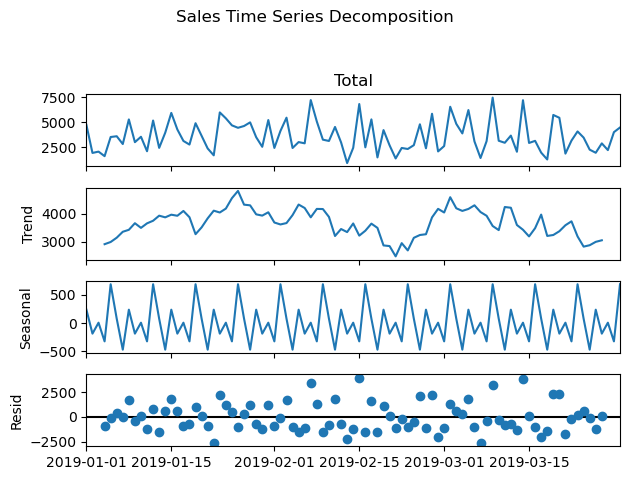

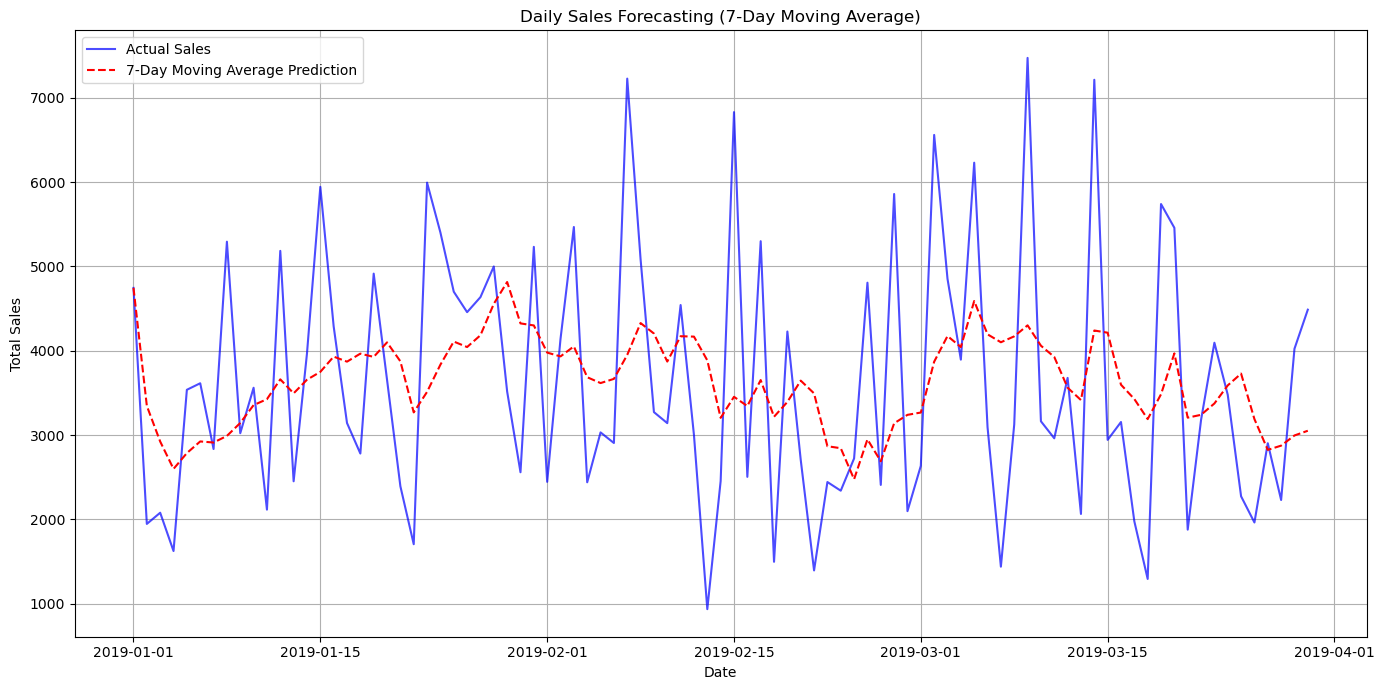


First 10 rows of daily sales with prediction:
        Date      Total  Prediction
0 2019-01-01  4745.1810  4745.18100
1 2019-01-02  1945.5030  3345.34200
2 2019-01-03  2078.1285  2922.93750
3 2019-01-04  1623.6885  2598.12525
4 2019-01-05  3536.6835  2785.83690
5 2019-01-06  3614.2050  2923.89825
6 2019-01-07  2834.2440  2911.09050
7 2019-01-08  5293.7325  2989.45500
8 2019-01-09  3021.3435  3143.14650
9 2019-01-10  3560.9490  3354.97800


In [ ]:
# Preparing data for time series analysis: aggregate daily sales
daily_sales = df.groupby('Date')['Total'].sum().reset_index()

# Set 'Date' as the index for time series operations
daily_sales = daily_sales.set_index('Date')

# Ensuring the index is a DatetimeIndex and fill missing dates if any for decomposition
daily_sales = daily_sales.asfreq('D', fill_value=0) # 'D' for daily frequency, fill missing with 0

print("Daily sales data prepared. Shape:", daily_sales.shape)
print(daily_sales.head())

# Performing seasonal decomposition to break down the time series into trend, seasonal, and residual components.
# model: 'additive' or 'multiplicative'. Additive is suitable when seasonal fluctuations are constant.
# period: The number of observations in a cycle (e.g., 7 for weekly seasonality).
try:
    result = seasonal_decompose(daily_sales['Total'], model='additive', period=7)

    # Plotting the  decomposition
    plt.figure(figsize=(12, 10))
    result.plot()
    plt.suptitle('Sales Time Series Decomposition', y=1.02) # Adjust suptitle position
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
    plt.show()
except ValueError as e:
    print(f"Error during seasonal decomposition: {e}")
    print("This often happens if the time series is too short or the period is too large for the data.")
    print(f"Number of daily sales entries: {len(daily_sales)}")
    if len(daily_sales) < 2 * 7: # At least two periods are usually needed for decomposition
        print("Consider increasing the amount of historical daily sales data for decomposition.")

# Reseting index to make 'Date' a column again for feature creation
daily_sales = daily_sales.reset_index()

# Creating additional time-based features for forecasting model consideration (though not directly used in SMA)
daily_sales['DayOfWeek'] = daily_sales['Date'].dt.dayofweek # 0=Monday, 6=Sunday
daily_sales['Month'] = daily_sales['Date'].dt.month
daily_sales['Year'] = daily_sales['Date'].dt.year

# Simple moving average prediction
# Calculates the mean of the 'Total' sales over a rolling window of 7 days.
daily_sales['Prediction'] = daily_sales['Total'].rolling(window=7, min_periods=1).mean()

# Plotting actual vs. predicted sales
plt.figure(figsize=(14, 7))
plt.plot(daily_sales['Date'], daily_sales['Total'], label='Actual Sales', color='blue', alpha=0.7)
plt.plot(daily_sales['Date'], daily_sales['Prediction'], label='7-Day Moving Average Prediction', color='red', linestyle='--')
plt.title('Daily Sales Forecasting (7-Day Moving Average)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nFirst 10 rows of daily sales with prediction:")
print(daily_sales[['Date', 'Total', 'Prediction']].head(10))

## 3. Cluster Formation - Customer Segmentation

Customer segmentation involves grouping customers based on their purchasing behavior. This allows for targeted marketing strategies and personalized customer experiences.

Customer data for clustering prepared. Shape: (2, 6)
  Customer type   Total_sum  Total_mean  Quantity_sum  Quantity_mean  \
0        Member  164223.444  327.791305          2785       5.558882   
1        Normal  158743.305  318.122856          2725       5.460922   

   Rating_mean  
0     6.940319  
1     7.005210  

Data scaled successfully. First 5 rows of scaled data:
   Total_sum  Total_mean  Quantity_sum  Quantity_mean  Rating_mean
0        1.0         1.0           1.0            1.0         -1.0
1       -1.0        -1.0          -1.0           -1.0          1.0


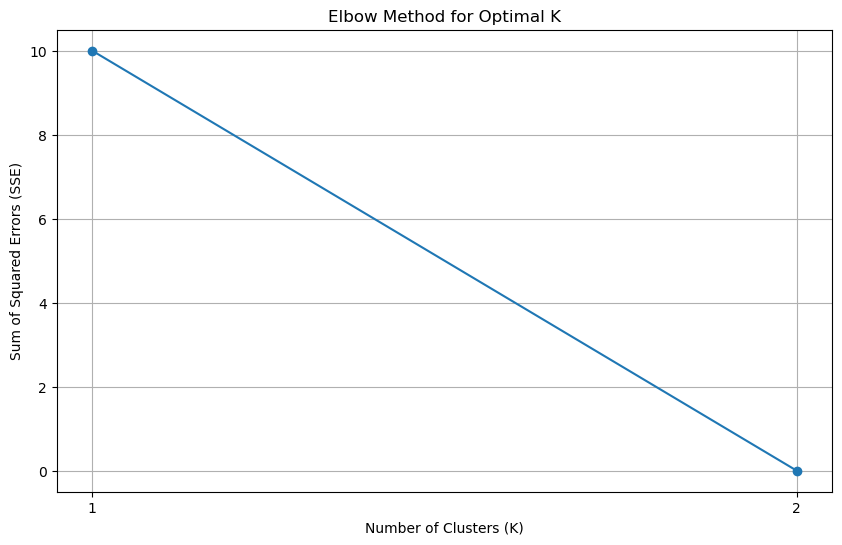


Elbow Method plot displayed. Choose K where the SSE curve starts to bend.

KMeans clustering completed. Assigned Clusters:
  Customer type  Cluster
0        Member        0
1        Normal        1

Cluster Centers (scaled features):
    Total_sum  Total_mean  Quantity_sum  Quantity_mean  Rating_mean
0        1.0         1.0           1.0            1.0         -1.0
1       -1.0        -1.0          -1.0           -1.0          1.0


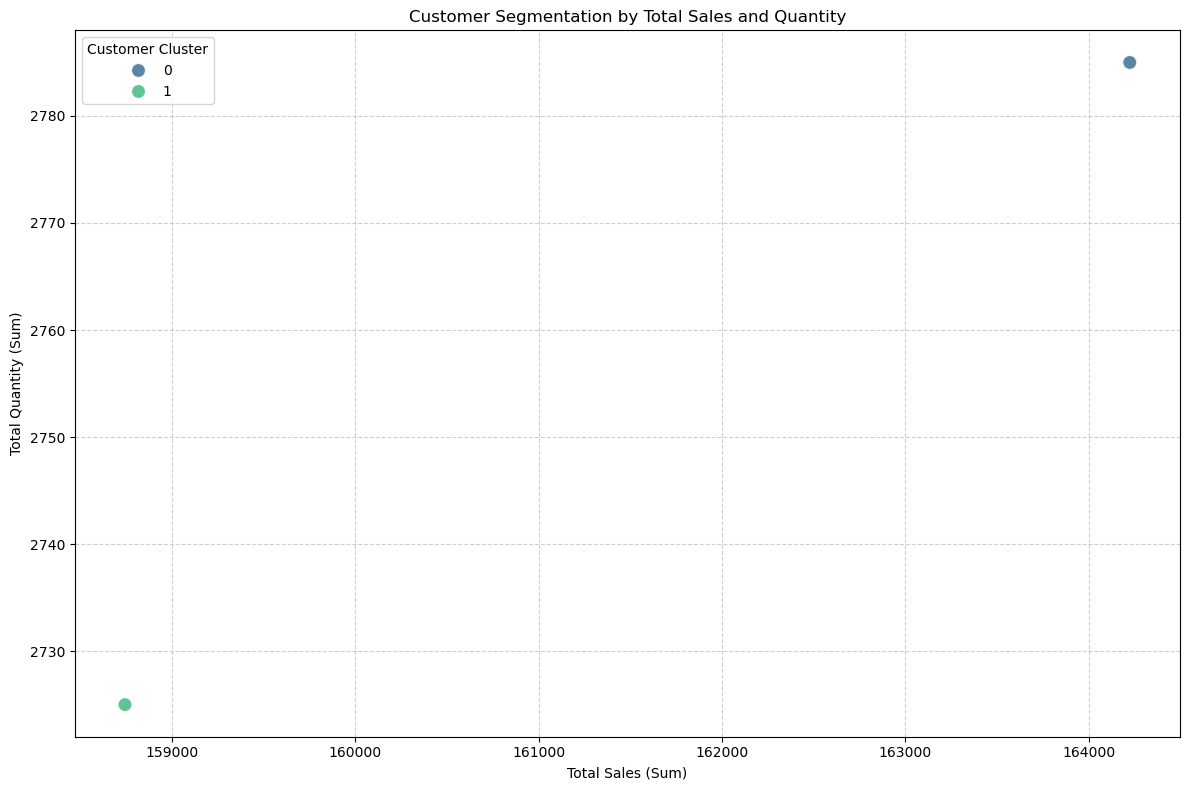


Customer segmentation plot displayed.
Summary of clusters:
           Total_sum  Total_mean  Quantity_sum  Quantity_mean  Rating_mean
Cluster                                                                  
0        164223.444  327.791305        2785.0       5.558882     6.940319
1        158743.305  318.122856        2725.0       5.460922     7.005210


In [6]:
# Prepare data for clustering: Aggregate customer-level metrics
# We'll group by 'Customer type' (assuming 'Customer type' is a proxy for individual customers or distinct segments)
# For a more granular customer segmentation, you would typically group by a unique customer ID if available.
customer_data = df.groupby('Customer type').agg(
    Total_sum=('Total', 'sum'),
    Total_mean=('Total', 'mean'),
    Quantity_sum=('Quantity', 'sum'),
    Quantity_mean=('Quantity', 'mean'),
    Rating_mean=('Rating', 'mean')
).reset_index()

print("Customer data for clustering prepared. Shape:", customer_data.shape)
print(customer_data.head())

# Select features for clustering (excluding the 'Customer type' identifier column)
features_for_clustering = customer_data.columns[1:]
X = customer_data[features_for_clustering]

# Standardize the data
# Scaling is crucial for KMeans as it relies on distances, and features with larger scales might dominate.
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

print("\nData scaled successfully. First 5 rows of scaled data:")
print(pd.DataFrame(scaled_data, columns=features_for_clustering).head())

# Determine optimal number of clusters using the Elbow Method (optional but recommended)
sse = []
k_range = range(1, len(customer_data) + 1)
if len(customer_data) > 1:
    for k in k_range:
        kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init for modern KMeans
        kmeans_model.fit(scaled_data)
        sse.append(kmeans_model.inertia_)

    plt.figure(figsize=(10, 6))
    plt.plot(k_range, sse, marker='o')
    plt.xlabel('Number of Clusters (K)')
    plt.ylabel('Sum of Squared Errors (SSE)')
    plt.title('Elbow Method for Optimal K')
    plt.xticks(k_range)
    plt.grid(True)
    plt.show()

    print("\nElbow Method plot displayed. Choose K where the SSE curve starts to bend.")

# Perform KMeans clustering
# n_clusters=3 is chosen based on the typical 'Member' vs 'Normal' assumption or prior analysis.
# In a real scenario, the optimal K would be determined from the Elbow Method or silhouette score.
n_clusters = min(3, len(customer_data)) # Ensure n_clusters doesn't exceed number of samples
if n_clusters < 1:
    print("Not enough data to perform clustering. Need at least 1 customer type.")
else:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init for modern KMeans
    customer_data['Cluster'] = kmeans.fit_predict(scaled_data)

    print("\nKMeans clustering completed. Assigned Clusters:")
    print(customer_data[['Customer type', 'Cluster']].head())
    print("\nCluster Centers (scaled features):\n", pd.DataFrame(kmeans.cluster_centers_, columns=features_for_clustering))

    # Visualize clusters
    # We are plotting 'Total_sum' and 'Quantity_sum' to see how clusters separate based on these key metrics.
    # sns.scatterplot is used for visualizing data points and coloring them by cluster.
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=customer_data,
    x='Total_sum',
    y='Quantity_sum',
    hue='Cluster',
    palette='viridis',
    s=100, # size of points
    alpha=0.8 # transparency of points
)
    plt.title('Customer Segmentation by Total Sales and Quantity')
    plt.xlabel('Total Sales (Sum)')
    plt.ylabel('Total Quantity (Sum)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Customer Cluster')
    plt.tight_layout()
    plt.show()

    print("\nCustomer segmentation plot displayed.")
    print("Summary of clusters:\n", customer_data.groupby('Cluster').mean(numeric_only=True))

## 4. Rules Mining - Product Association Rules

This section focuses on finding associations between specific products rather than product lines, which can provide more detailed insights for cross-selling and product recommendations.

In [8]:
# Create product basket data, similar to market basket analysis, but at the individual 'Product' level.
# Each row represents an invoice, and columns represent individual products.
product_basket = (df.groupby(['Invoice ID', 'Product line'])['Quantity']
          .sum().unstack().reset_index().fillna(0))

# Convert to binary format (1 if product was purchased, 0 otherwise)
# Reusing the encode_units function defined earlier.
product_basket_sets = product_basket.iloc[:,1:].applymap(encode_units)

print("Product basket data for association rules prepared. Shape:", product_basket_sets.shape)
print(product_basket_sets.head())

# Generate frequent itemsets for individual products
# min_support is set to 0.05 (5% of transactions must contain the itemset).
product_itemsets = apriori(product_basket_sets, min_support=0.05, use_colnames=True)

print("\nFrequent Product Itemsets found:", len(product_itemsets))
print(product_itemsets.head())

# Generate association rules for products
# metric="confidence": Measures how often items in 'consequents' appear given the items in 'antecedents'.
# min_threshold=0.7: Only rules with confidence of 70% or higher are considered.
product_rules = association_rules(product_itemsets, metric="confidence", min_threshold=0.7)

# Display top product rules, sorted by 'lift'
print("\nTop Product Association Rules (sorted by Lift):")
print(product_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False).head(10))

if product_rules.empty:
    print("No product association rules found with the given min_support and min_threshold. Try adjusting these values.")

Product basket data for association rules prepared. Shape: (1000, 6)
Product line  Electronic accessories  Fashion accessories  Food and beverages  \
0                                  0                    0                   1   
1                                  0                    0                   0   
2                                  0                    0                   0   
3                                  0                    0                   0   
4                                  0                    1                   0   

Product line  Health and beauty  Home and lifestyle  Sports and travel  
0                             0                   0                  0  
1                             1                   0                  0  
2                             0                   0                  1  
3                             1                   0                  0  
4                             0                   0                  0  

Frequ

/tmp/ipykernel_612432/3286384084.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  product_basket_sets = product_basket.iloc[:,1:].applymap(encode_units)
/home/bradley-s/anaconda3/lib/python3.12/site-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


## 5. Sequence Discovery - Customer Purchase Patterns

Sequence discovery aims to find patterns in the order of purchases. This can reveal common customer journeys or subsequent purchases, which is valuable for targeted follow-up marketing.

In [ ]:
# Create sequence data: Group products purchased within the same Invoice ID and Date.
# This assumes that products within the same invoice are purchased at roughly the same time, forming a single 'sequence' unit.
# If temporal order within an invoice is critical, more detailed timestamp data would be needed.
sequences_df = df.sort_values(by=['Invoice ID', 'Time']).groupby(['Invoice ID'])['Product line'].apply(list).reset_index(name='Sequence')

print("Sequences prepared. First 5 sequences:")
print(sequences_df.head())

# Analyze common sequences using a Counter.
# This specific analysis looks for consecutive pairs of products within each transaction sequence.
from collections import Counter
sequence_counter = Counter()

for seq in sequences_df['Sequence']:
    # Iterate through each sequence to find consecutive product pairs
    for i in range(len(seq) - 1):
        sequence_counter[(seq[i], seq[i+1])] += 1

# Get the most common sequences (product pairs in this case)
common_sequences = sequence_counter.most_common(10)

print("\nMost Common Product Sequences (Pairs):")
if common_sequences:
    for seq_pair, count in common_sequences:
        print(f"Product A: '{seq_pair[0]}' -> Product B: '{seq_pair[1]}' (Occurrences: {count})")
else:
    print("No common sequences found. This might happen if there are very few transactions or highly varied product purchases.")



Sequences prepared. First 5 sequences:
    Invoice ID               Sequence
0  101-17-6199   [Food and beverages]
1  101-81-4070    [Health and beauty]
2  102-06-2002    [Sports and travel]
3  102-77-2261    [Health and beauty]
4  105-10-6182  [Fashion accessories]

Most Common Product Sequences (Pairs):
No common sequences found. This might happen if there are very few transactions or highly varied product purchases.
